In [32]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Portfolio
portfolio_data = {
    'Ticker': ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'WIPRO.NS'],
    'Quantity': [10, 5, 20, 15, 50],
    'Buy_Price': [2400, 3200, 1450, 1350, 120]
}
df = pd.DataFrame(portfolio_data)
df

,Ticker,Quantity,Buy_Price
0,RELIANCE.NS,10,2400
1,TCS.NS,5,3200
2,HDFCBANK.NS,20,1450
3,INFY.NS,15,1350
4,WIPRO.NS,50,120


In [39]:
#Robust price fetcher
def get_live_price(ticker):
    try:
        stock = yf.Ticker(ticker)
        
        # 5 days ka history lete hain taaki weekend par bhi data mil sake
        data = stock.history(period='5d') 
        if not data.empty:
            return data['Close'].iloc[-1]
        return 0.0
    except Exception as e:
        return 0.0
        

print("Prices fetch ho rahe hain...")
df['Current_Price'] = df['Ticker'].apply(get_live_price)

#  Handling Missing Data (NaN Fix)
# Agar kisi stock ka price nahi mila, toh use 0 kar do taaki calculation na ruke
df['Current_Price'] = df['Current_Price'].fillna(0)

# Calculations
df['Total_Investment'] = df['Quantity'] * df['Buy_Price']
df['Current_Value'] = df['Quantity'] * df['Current_Price']
df['Profit_Loss'] = df['Current_Value'] - df['Total_Investment']
df = df.round(2)
# Output Display
print("\n--- Portfolio Summary Table ---")
print(df)

#  Final Summary Calculations
total_invested = df['Total_Investment'].sum()
total_current_value = df['Current_Value'].sum()
overall_pl = total_current_value - total_invested

if total_invested > 0:
    pl_percentage = (overall_pl / total_invested) * 100
else:
    pl_percentage = 0

print("\n" + "="*30)
print(f"💰 Total Invested: ₹{total_invested:,.2f}")
print(f"📈 Current Value:  ₹{total_current_value:,.2f}")
print(f"📊 Net Profit/Loss: ₹{overall_pl:,.2f} ({pl_percentage:.2f}%)")
print("="*30)

df # Output table dikhayega

Prices fetch ho rahe hain...

--- Portfolio Summary Table ---
        Ticker  Quantity  Buy_Price  Current_Price  Total_Investment  \
0  RELIANCE.NS        10       2400        1343.40             24000   
1       TCS.NS         5       3200        2521.80             16000   
2  HDFCBANK.NS        20       1450         784.35             29000   
3      INFY.NS        15       1350        1240.60             20250   
4     WIPRO.NS        50        120         202.76              6000   

   Current_Value  Profit_Loss  
0        13434.0     -10566.0  
1        12609.0      -3391.0  
2        15687.0     -13313.0  
3        18609.0      -1641.0  
4        10138.0       4138.0  

💰 Total Invested: ₹95,250.00
📈 Current Value:  ₹70,477.00
📊 Net Profit/Loss: ₹-24,773.00 (-26.01%)


,Ticker,Quantity,Buy_Price,Current_Price,Total_Investment,Current_Value,Profit_Loss
0,RELIANCE.NS,10,2400,1343.40,24000,13434.0,-10566.0
1,TCS.NS,5,3200,2521.80,16000,12609.0,-3391.0
2,HDFCBANK.NS,20,1450,784.35,29000,15687.0,-13313.0
3,INFY.NS,15,1350,1240.60,20250,18609.0,-1641.0
4,WIPRO.NS,50,120,202.76,6000,10138.0,4138.0


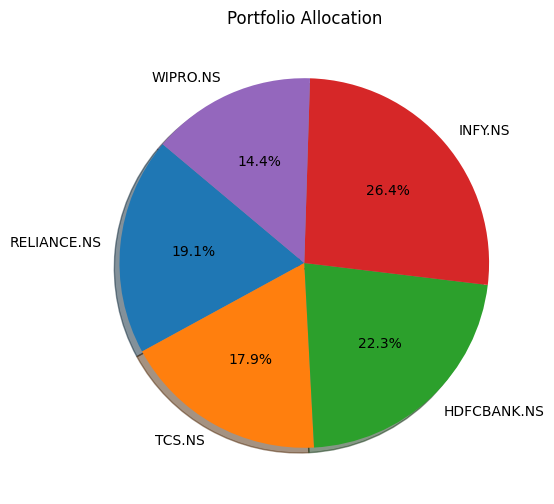

In [35]:
# 1. first of all, fix the null values
df['Current_Value'] = df['Current_Value'].fillna(0)
df['Ticker'] = df['Ticker'].fillna("Unknown")

# 2. now creat the chart
plt.figure(figsize=(8,6))

# Create the Chart only for those whose value is greater than zero
data_to_plot = df[df['Current_Value'] > 0]

plt.pie(data_to_plot['Current_Value'], 
        labels=data_to_plot['Ticker'], 
        autopct='%1.1f%%', 
        shadow=True, 
        startangle=140)

plt.title('Portfolio Allocation')
plt.show()

In [36]:
# Final Summary Calculations
total_invested = df['Total_Investment'].sum()
total_current_value = df['Current_Value'].sum()
overall_pl = total_current_value - total_invested
pl_percentage = (overall_pl / total_invested) * 100

print("=========================================")
print(f"💰 Total Invested: ₹{total_invested:,.2f}")
print(f"📈 Current Value:  ₹{total_current_value:,.2f}")
print(f"📊 Net Profit/Loss: ₹{overall_pl:,.2f} ({pl_percentage:.2f}%)")
print("=========================================")

💰 Total Invested: ₹95,250.00
📈 Current Value:  ₹70,477.00
📊 Net Profit/Loss: ₹-24,773.00 (-26.01%)


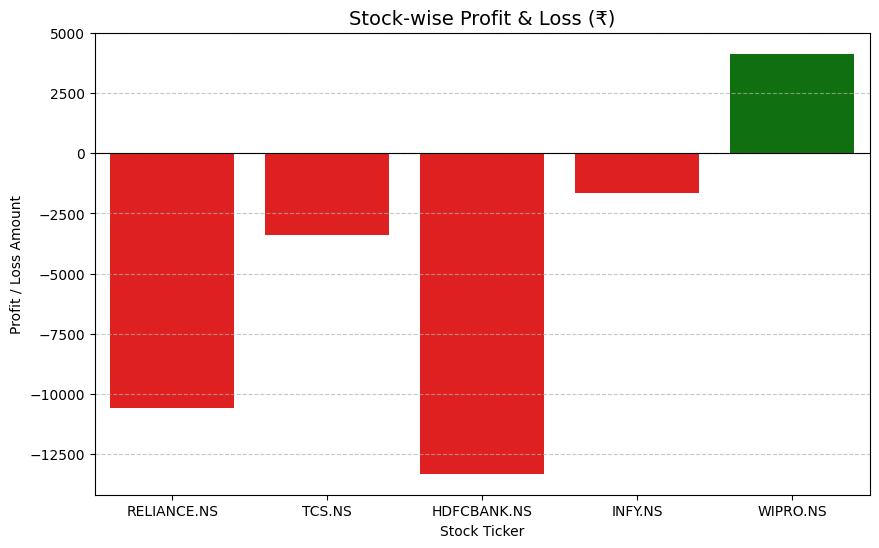

In [37]:
import seaborn as sns
# 1. Take only those stocks for which data is available
df_clean = df.dropna(subset=['Profit_Loss'])

# 2. Bar Chart Setup
plt.figure(figsize=(10, 6))
colors = ['green' if x >= 0 else 'red' for x in df_clean['Profit_Loss']]

sns.barplot(x='Ticker', y='Profit_Loss', data=df_clean, palette=colors)

# 3. Aesthetics
plt.axhline(0, color='black', linewidth=0.8) # Zero line dikhane ke liye
plt.title('Stock-wise Profit & Loss (₹)', fontsize=14)
plt.ylabel('Profit / Loss Amount')
plt.xlabel('Stock Ticker')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()